# 🔍 Scanner Multi-TF — ETH/BTC, SOL/ETH, LINK/ETH
Test sur 1h et 4h — 90 jours

In [1]:
import ccxt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
print('✅ Imports OK')

✅ Imports OK


## 1. Configuration

In [2]:
CANDIDATE_PAIRS = [
    ('ETH/USDT', 'BTC/USDT'),
    ('SOL/USDT', 'ETH/USDT'),
    ('LINK/USDT', 'ETH/USDT'),
    ('AAVE/USDT', 'ETH/USDT'),   # Référence — notre paire actuelle
    ('SOL/USDT',  'BTC/USDT'),
    ('AVAX/USDT', 'ETH/USDT'),
    ('UNI/USDT',  'ETH/USDT'),
    ('ARB/USDT',  'ETH/USDT'),
    ('OP/USDT',   'ETH/USDT'),
]

TIMEFRAMES = ['1h', '4h']
DAYS       = 90
WINDOW     = 50   # Fenêtre rolling adaptée : 50 bougies = 50h sur 1h, 200h sur 4h

ALL_SYMBOLS = list(set([s for pair in CANDIDATE_PAIRS for s in pair]))
print(f'Symboles  : {ALL_SYMBOLS}')
print(f'Paires    : {len(CANDIDATE_PAIRS)}')
print(f'TF testés : {TIMEFRAMES}')
print(f'Total     : {len(CANDIDATE_PAIRS) * len(TIMEFRAMES)} combinaisons')

Symboles  : ['AVAX/USDT', 'OP/USDT', 'BTC/USDT', 'AAVE/USDT', 'ETH/USDT', 'LINK/USDT', 'SOL/USDT', 'ARB/USDT', 'UNI/USDT']
Paires    : 9
TF testés : ['1h', '4h']
Total     : 18 combinaisons


## 2. Téléchargement

In [3]:
def fetch_close(symbol, timeframe='1h', days=90):
    exchange = ccxt.binance({'enableRateLimit': True})
    since = int((datetime.now() - timedelta(days=days)).timestamp() * 1000)
    all_ohlcv = []
    while True:
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
            if not ohlcv: break
            all_ohlcv.extend(ohlcv)
            since = ohlcv[-1][0] + 1
            tf_ms = {'15m': 15*60*1000, '1h': 60*60*1000, '4h': 4*60*60*1000}
            if ohlcv[-1][0] >= int(datetime.now().timestamp() * 1000) - tf_ms.get(timeframe, 60*60*1000):
                break
        except Exception as e:
            print(f'⚠️ {symbol} {timeframe}: {e}')
            break
    if not all_ohlcv: return None
    df = pd.DataFrame(all_ohlcv, columns=['timestamp','open','high','low','close','volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.set_index('timestamp')[['close']]
    df = df[~df.index.duplicated(keep='first')]
    df.columns = [symbol]
    return df

# Téléchargement pour chaque TF
prices = {}
for tf in TIMEFRAMES:
    prices[tf] = {}
    print(f'\n📥 Téléchargement {tf}...')
    for sym in ALL_SYMBOLS:
        df = fetch_close(sym, timeframe=tf, days=DAYS)
        if df is not None:
            prices[tf][sym] = df
            print(f'  ✅ {sym:<15} — {len(df)} bougies')
        else:
            print(f'  ❌ {sym}')

print('\n✅ Téléchargement terminé')


📥 Téléchargement 1h...
  ✅ AVAX/USDT       — 2160 bougies
  ✅ OP/USDT         — 2160 bougies
  ✅ BTC/USDT        — 2160 bougies
  ✅ AAVE/USDT       — 2160 bougies
  ✅ ETH/USDT        — 2160 bougies
  ✅ LINK/USDT       — 2160 bougies
  ✅ SOL/USDT        — 2160 bougies
  ✅ ARB/USDT        — 2160 bougies
  ✅ UNI/USDT        — 2160 bougies

📥 Téléchargement 4h...
  ✅ AVAX/USDT       — 540 bougies
  ✅ OP/USDT         — 540 bougies
  ✅ BTC/USDT        — 540 bougies
  ✅ AAVE/USDT       — 540 bougies
  ✅ ETH/USDT        — 540 bougies
  ✅ LINK/USDT       — 540 bougies
  ✅ SOL/USDT        — 540 bougies
  ✅ ARB/USDT        — 540 bougies
  ✅ UNI/USDT        — 540 bougies

✅ Téléchargement terminé


## 3. Analyse

In [4]:
def compute_hurst(series, max_lag=50):
    lags = range(2, max_lag)
    tau  = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

def compute_half_life(spread):
    lag   = spread.shift(1).dropna()
    delta = spread.diff().dropna()
    lag, delta = lag.align(delta, join='inner')
    reg = OLS(delta, add_constant(lag)).fit()
    if reg.params[0] >= 0: return np.inf
    return -np.log(2) / reg.params[0]

def analyze_pair(sym1, sym2, prices_tf, tf, window=50):
    if sym1 not in prices_tf or sym2 not in prices_tf: return None
    df = pd.concat([prices_tf[sym1], prices_tf[sym2]], axis=1).dropna()
    if len(df) < window * 3: return None

    split = int(len(df) * 0.8)
    train = df.iloc[:split]

    _, pvalue, _ = coint(train[sym1], train[sym2])

    rolling_cov = df[sym1].rolling(window).cov(df[sym2])
    rolling_var = df[sym2].rolling(window).var()
    ratio  = rolling_cov / rolling_var
    spread = (df[sym1] - ratio * df[sym2]).dropna()

    adf_pvalue      = adfuller(spread.iloc[split:])[1]
    hurst           = compute_hurst(spread.values)
    half_life       = compute_half_life(spread)
    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
    z = z.dropna()
    crossings = int(((z.shift(1) * z) < 0).sum())
    amplitude = z[(z > 2) | (z < -2)].abs().mean()

    # Half-life en heures pour comparaison inter-TF
    tf_hours = {'1h': 1, '4h': 4, '15m': 0.25}
    hl_hours = half_life * tf_hours.get(tf, 1)

    return {
        'pair'        : f'{sym1} / {sym2}',
        'tf'          : tf,
        'coint_pvalue': round(pvalue, 5),
        'adf_oos'     : round(adf_pvalue, 5),
        'hurst'       : round(hurst, 3),
        'half_life'   : round(half_life, 1),
        'hl_hours'    : round(hl_hours, 1),
        'zero_cross'  : crossings,
        'amplitude'   : round(float(amplitude), 3) if not np.isnan(amplitude) else 0,
        'n_candles'   : len(df),
    }

print('🔬 Scan en cours...\n')
results = []
for tf in TIMEFRAMES:
    print(f'--- {tf} ---')
    for s1, s2 in CANDIDATE_PAIRS:
        res = analyze_pair(s1, s2, prices[tf], tf, window=WINDOW)
        if res:
            coint_ok = '✅' if res['coint_pvalue'] < 0.05 else '⚠️'
            hurst_ok = '✅' if res['hurst'] < 0.5 else '❌'
            print(f"  {s1:<12}/{s2:<12} | Coint={coint_ok}{res['coint_pvalue']:.4f} | Hurst={hurst_ok}{res['hurst']} | HL={res['hl_hours']}h | ZC={res['zero_cross']}")
            results.append(res)
        else:
            print(f'  {s1}/{s2} → données insuffisantes')
    print()

df_results = pd.DataFrame(results)
print(f'\n✅ {len(df_results)} combinaisons analysées')

🔬 Scan en cours...

--- 1h ---
  ETH/USDT    /BTC/USDT     | Coint=⚠️0.9525 | Hurst=❌0.589 | HL=108.7h | ZC=66
  SOL/USDT    /ETH/USDT     | Coint=⚠️0.7147 | Hurst=❌0.551 | HL=114.1h | ZC=66
  LINK/USDT   /ETH/USDT     | Coint=⚠️0.6687 | Hurst=❌0.528 | HL=113.1h | ZC=68
  AAVE/USDT   /ETH/USDT     | Coint=⚠️0.2034 | Hurst=❌0.574 | HL=139.6h | ZC=66
  SOL/USDT    /BTC/USDT     | Coint=⚠️0.5419 | Hurst=❌0.517 | HL=102.1h | ZC=68
  AVAX/USDT   /ETH/USDT     | Coint=⚠️0.9314 | Hurst=✅0.478 | HL=81.2h | ZC=72
  UNI/USDT    /ETH/USDT     | Coint=⚠️0.5720 | Hurst=✅0.498 | HL=91.6h | ZC=60
  ARB/USDT    /ETH/USDT     | Coint=⚠️0.5163 | Hurst=❌0.513 | HL=94.5h | ZC=80
  OP/USDT     /ETH/USDT     | Coint=⚠️0.6498 | Hurst=❌0.551 | HL=87.0h | ZC=67

--- 4h ---
  ETH/USDT    /BTC/USDT     | Coint=⚠️0.9388 | Hurst=❌0.622 | HL=573.3h | ZC=12
  SOL/USDT    /ETH/USDT     | Coint=⚠️0.7625 | Hurst=❌0.651 | HL=612.8h | ZC=12
  LINK/USDT   /ETH/USDT     | Coint=⚠️0.7381 | Hurst=❌0.599 | HL=458.2h | ZC=16
 

## 4. Scoring et classement

In [5]:
def score_pair(row):
    score = 0
    # Hurst (30 pts)
    if   row['hurst'] < 0.3: score += 30
    elif row['hurst'] < 0.4: score += 20
    elif row['hurst'] < 0.5: score += 10
    # Cointégration (20 pts)
    if   row['coint_pvalue'] < 0.01: score += 20
    elif row['coint_pvalue'] < 0.05: score += 12
    # ADF OOS (20 pts)
    if   row['adf_oos'] < 0.01: score += 20
    elif row['adf_oos'] < 0.05: score += 12
    # Half-life en heures (20 pts) — idéal 2h-48h
    hl = row['hl_hours']
    if   2  <= hl <= 24:  score += 20
    elif 1  <= hl <= 72:  score += 10
    # Zero-crossings (10 pts)
    if   row['zero_cross'] > 100: score += 10
    elif row['zero_cross'] > 50:  score += 5
    return score

df_results['score'] = df_results.apply(score_pair, axis=1)
df_results = df_results.sort_values('score', ascending=False).reset_index(drop=True)

print('🏆 CLASSEMENT FINAL')
print('=' * 110)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_results[['pair','tf','score','coint_pvalue','adf_oos','hurst','hl_hours','zero_cross','amplitude']].to_string())

🏆 CLASSEMENT FINAL
                    pair  tf  score  coint_pvalue  adf_oos  hurst  hl_hours  zero_cross  amplitude
0    UNI/USDT / ETH/USDT  1h     35        0.5720   0.0087 0.4980   91.6000          60     2.6900
1    SOL/USDT / BTC/USDT  1h     25        0.5419   0.0076 0.5170  102.1000          68     2.5900
2    ETH/USDT / BTC/USDT  1h     17        0.9525   0.0311 0.5890  108.7000          66     2.5490
3    SOL/USDT / ETH/USDT  1h     17        0.7147   0.0465 0.5510  114.1000          66     2.5240
4   AVAX/USDT / ETH/USDT  1h     15        0.9314   0.0619 0.4780   81.2000          72     2.6110
5   LINK/USDT / ETH/USDT  1h      5        0.6687   0.1419 0.5280  113.1000          68     2.5420
6   AAVE/USDT / ETH/USDT  1h      5        0.2034   0.1905 0.5740  139.6000          66     2.6630
7    ARB/USDT / ETH/USDT  1h      5        0.5163   0.1831 0.5130   94.5000          80     2.6270
8     OP/USDT / ETH/USDT  1h      5        0.6498   0.1481 0.5510   87.0000          67   

## 5. Graphiques Top 3

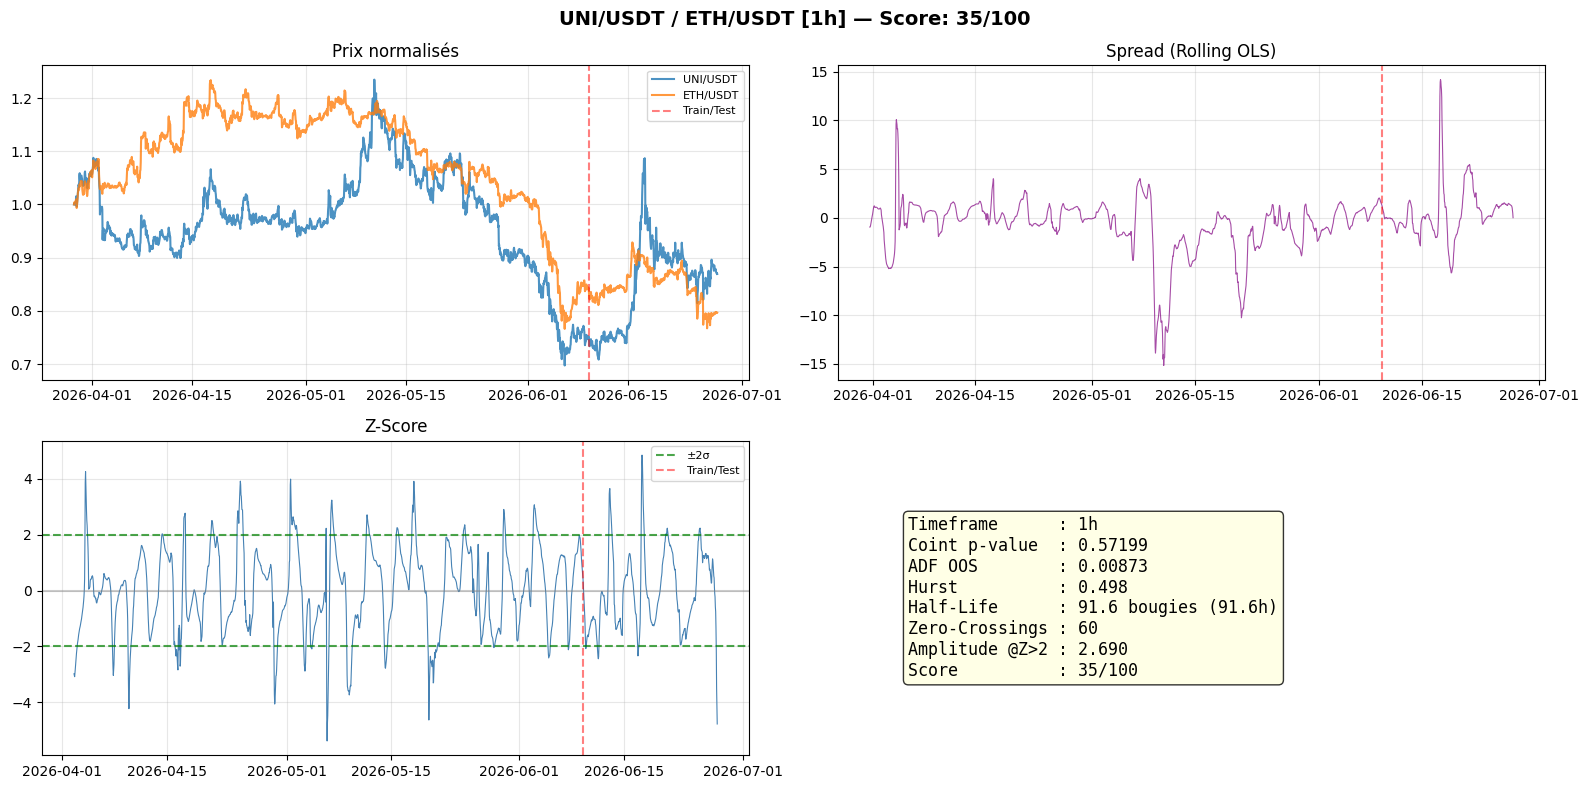

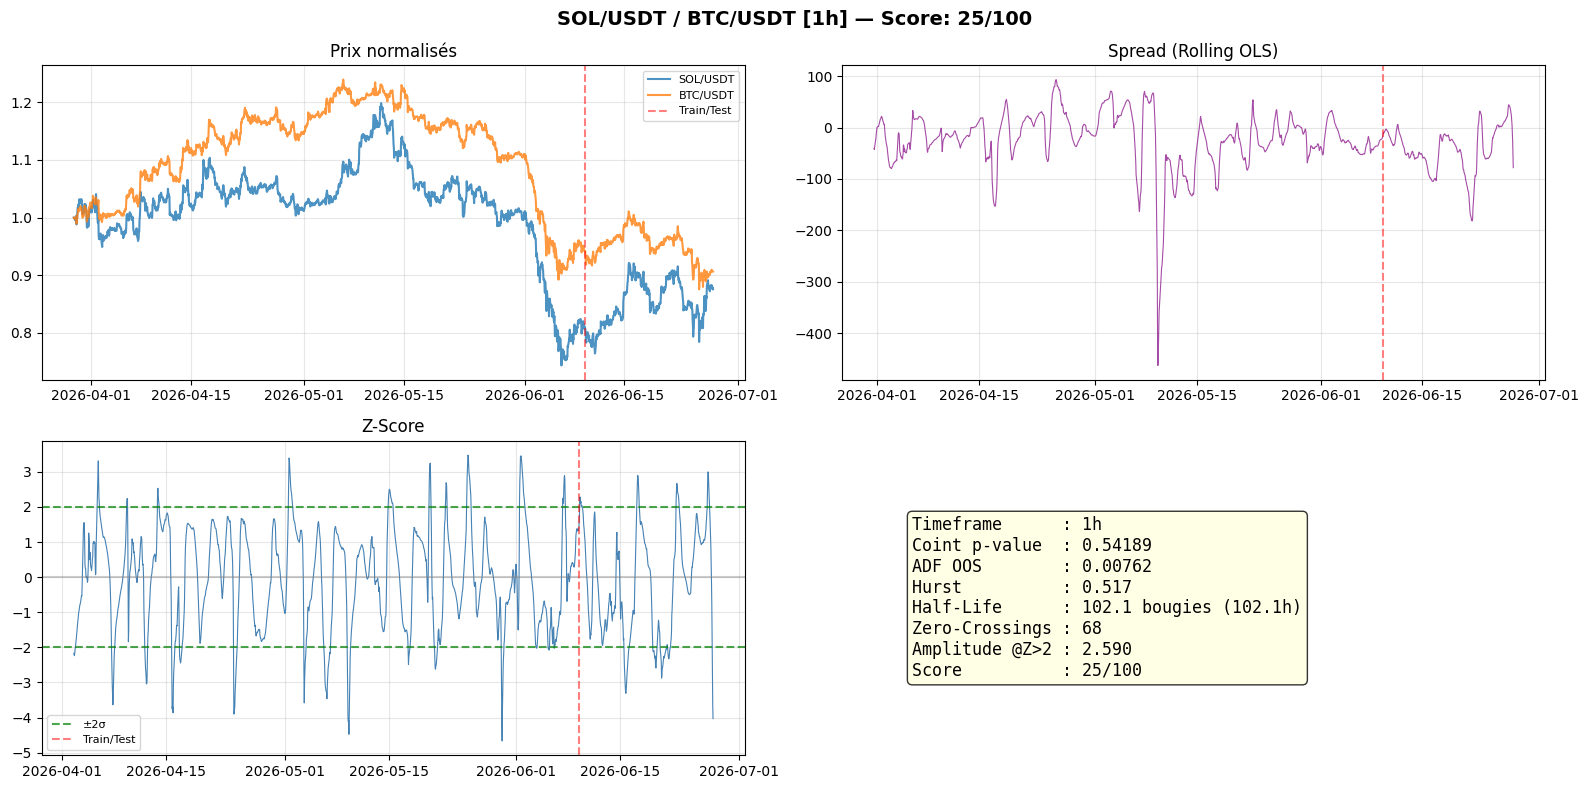

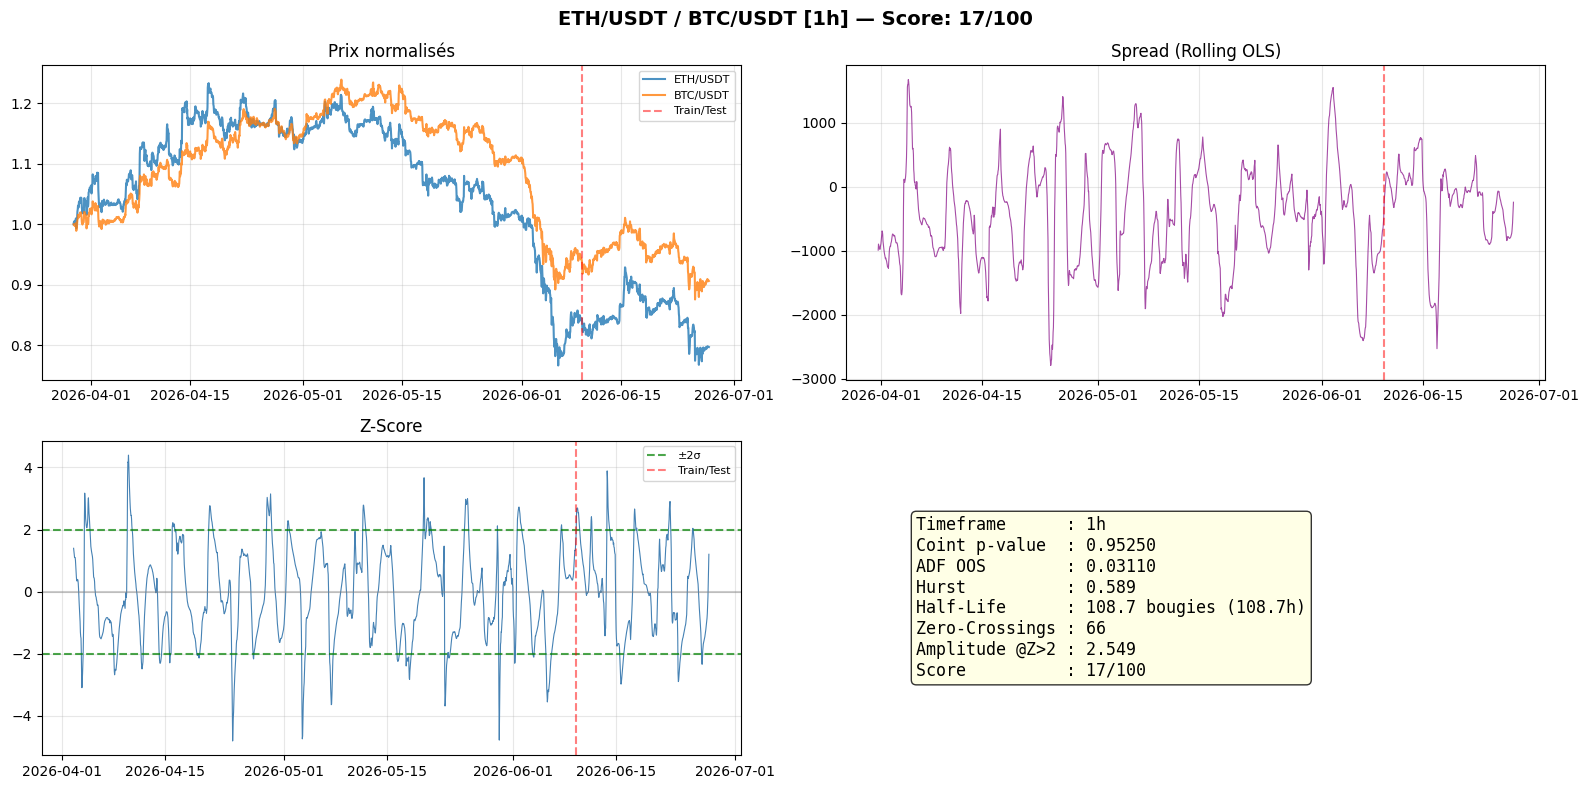

In [6]:
top3 = df_results.head(3)

for _, row in top3.iterrows():
    parts = row['pair'].split(' / ')
    sym1, sym2 = parts[0].strip(), parts[1].strip()
    tf = row['tf']

    if sym1 not in prices[tf] or sym2 not in prices[tf]: continue

    df = pd.concat([prices[tf][sym1], prices[tf][sym2]], axis=1).dropna()
    split = int(len(df) * 0.8)

    rolling_cov = df[sym1].rolling(WINDOW).cov(df[sym2])
    rolling_var = df[sym2].rolling(WINDOW).var()
    ratio  = rolling_cov / rolling_var
    spread = df[sym1] - ratio * df[sym2]
    zscore = (spread - spread.rolling(WINDOW).mean()) / spread.rolling(WINDOW).std()
    zscore = zscore.dropna()

    fig = plt.figure(figsize=(16, 8))
    fig.suptitle(f"{sym1} / {sym2} [{tf}] — Score: {row['score']}/100", fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 2, figure=fig)

    ax1 = fig.add_subplot(gs[0, 0])
    norm1 = df[sym1] / df[sym1].iloc[0]
    norm2 = df[sym2] / df[sym2].iloc[0]
    ax1.plot(norm1.index, norm1, label=sym1, alpha=0.8)
    ax1.plot(norm2.index, norm2, label=sym2, alpha=0.8)
    ax1.axvline(df.index[split], color='red', linestyle='--', alpha=0.5, label='Train/Test')
    ax1.set_title('Prix normalisés')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(spread.index, spread, color='purple', alpha=0.7, linewidth=0.8)
    ax2.axvline(df.index[split], color='red', linestyle='--', alpha=0.5)
    ax2.set_title('Spread (Rolling OLS)')
    ax2.grid(alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(zscore.index, zscore, color='steelblue', linewidth=0.8)
    ax3.axhline( 2, color='green', linestyle='--', alpha=0.7, label='±2σ')
    ax3.axhline(-2, color='green', linestyle='--', alpha=0.7)
    ax3.axhline( 0, color='gray',  linestyle='-',  alpha=0.4)
    ax3.axvline(df.index[split], color='red', linestyle='--', alpha=0.5, label='Train/Test')
    ax3.set_title('Z-Score')
    ax3.legend(fontsize=8)
    ax3.grid(alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    txt = (
        f"Timeframe      : {tf}\n"
        f"Coint p-value  : {row['coint_pvalue']:.5f}\n"
        f"ADF OOS        : {row['adf_oos']:.5f}\n"
        f"Hurst          : {row['hurst']:.3f}\n"
        f"Half-Life      : {row['half_life']:.1f} bougies ({row['hl_hours']:.1f}h)\n"
        f"Zero-Crossings : {row['zero_cross']}\n"
        f"Amplitude @Z>2 : {row['amplitude']:.3f}\n"
        f"Score          : {row['score']}/100"
    )
    ax4.text(0.1, 0.5, txt, transform=ax4.transAxes, fontsize=12,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()
    print()

## 6. Export

In [7]:
df_results.to_csv('scan_multitf_results.csv', index=False)
print(f'💾 scan_multitf_results.csv — {len(df_results)} combinaisons')
print('\n🏆 TOP 3 RECOMMANDÉES :')
for i, (_, row) in enumerate(df_results.head(3).iterrows()):
    print(f'  {i+1}. {row["pair"]} [{row["tf"]}] — Score {row["score"]}/100 | Hurst {row["hurst"]} | HL {row["hl_hours"]}h')

💾 scan_multitf_results.csv — 18 combinaisons

🏆 TOP 3 RECOMMANDÉES :
  1. UNI/USDT / ETH/USDT [1h] — Score 35/100 | Hurst 0.498 | HL 91.6h
  2. SOL/USDT / BTC/USDT [1h] — Score 25/100 | Hurst 0.517 | HL 102.1h
  3. ETH/USDT / BTC/USDT [1h] — Score 17/100 | Hurst 0.589 | HL 108.7h
